In [22]:
import numpy as np
import os
import sys
import gc
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import nibabel as nib
import ants

from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import AgglomerativeClustering
from tqdm import tqdm
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from sklearn.decomposition import TruncatedSVD
from scipy.stats import zscore
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import importlib
from collections import defaultdict
import traceback
from matplotlib.backends.backend_pdf import PdfPages
from typing import Union
from joblib import Parallel, delayed
from multiprocessing import Pool, cpu_count
import joblib
from scipy.ndimage import percentile_filter, gaussian_filter
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.decomposition import FactorAnalysis
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import fftconvolve
import pickle
import tifffile


Load Fish Arrays and Responders

In [10]:
BASE_DIR = Path("/mnt/storage-raid10/Yun/analysis_output/chemogenetic")
PROJ_ID = "hcrt-trpv1_huc-h2b-g8m_csn_120min"
PROJ_CTRL = "huc-h2b-g8m_csn_120min"
PHASIC_DPRIME_THRESH = 0.5

RESPONSE_TYPES = ["tonic_pos", "tonic_neg", "phasic_pos", "phasic_neg"]

In [18]:
#low mem method to load fish data and responders

#Expt fish list
expt_fish_list = [
            "251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4",
            "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
            "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2",
            "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
            "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2", 
            "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3",
            "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1",
            "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2",
            "260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1"
]


def process_fish(fish_id):
    fish_dir = BASE_DIR / PROJ_ID / fish_id
    
    try:
        f_tonic = np.load(fish_dir / "f_tonic.npy", mmap_mode="r")
        f_phasic = np.load(fish_dir / "f_phasic.npy", mmap_mode="r")
        
      
        tonic_pos_idx = np.load(fish_dir / "tonic_pos_glm_iaaft_nullp99_idxs.npy")
        tonic_neg_idx = np.load(fish_dir / "tonic_neg_glm_iaaft_nullp99_idxs.npy")
        dprime = np.load(fish_dir / "phasic_dprime_cells_raw.npy")

      
        all_tonic_idx = np.union1d(tonic_pos_idx, tonic_neg_idx)
        all_phasic_idx = np.where(np.abs(dprime) >= PHASIC_DPRIME_THRESH)[0]

     
        tonic_slice = np.array(f_tonic[all_tonic_idx, :])
        phasic_slice = np.array(f_phasic[all_phasic_idx, :])

        return fish_id, tonic_slice, phasic_slice

    except FileNotFoundError:
        return None

# Main Execution
tonic_data = {}
phasic_data = {}

print("Started processing fish folders")


with ThreadPoolExecutor(max_workers=3) as executor:
    results = executor.map(process_fish, expt_fish_list)

for result in results:
    if result is not None:
        fish_id, t_res, p_res = result
        tonic_data[fish_id] = t_res
        phasic_data[fish_id] = p_res

print(f"Completed processing for {len(tonic_data)} fish.")


Started processing fish folders
Completed processing for 9 fish.


In [19]:
'''

#For later with control

ctrl_ID_1 = ''
ctrl_ID_2 = ''
ctrl_ID_3 = ''
ctrl_ID_4 = ''
ctrl_ID_5 = ''
ctrl_ID_6 = ''
ctrl_ID_7 = ''

#ctrl_expt_ID_list = [ctrl_ID_1, ctrl_ID_2, ctrl_ID_3, ctrl_ID_4, ctrl_ID_5, ctrl_ID_6, ctrl_ID_7]

expt_ID_list = ctrl_expt_ID_list + expt_fish_list

'''

"\n\n#For later with control\n\nctrl_ID_1 = ''\nctrl_ID_2 = ''\nctrl_ID_3 = ''\nctrl_ID_4 = ''\nctrl_ID_5 = ''\nctrl_ID_6 = ''\nctrl_ID_7 = ''\n\n#ctrl_expt_ID_list = [ctrl_ID_1, ctrl_ID_2, ctrl_ID_3, ctrl_ID_4, ctrl_ID_5, ctrl_ID_6, ctrl_ID_7]\n\nexpt_ID_list = ctrl_expt_ID_list + expt_fish_list\n\n"

In [20]:
from scipy.stats import zscore

z_phasic = {}

print("Starting batch Z-score normalization for all experimental fish...\n")


for fish_id in expt_fish_list:
  
    if fish_id in phasic_data:
    
        raw_phasic_traces = phasic_data[fish_id]

        z_phasic_traces = zscore(raw_phasic_traces, axis=1)

        z_phasic[fish_id] = z_phasic_traces
        
        print(f"Normalization Complete for: {fish_id}")
        print(f"Matrix Shape: {z_phasic_traces.shape}")
        print(f"Mean Verification: {z_phasic_traces.mean():.3f} | Std Dev: {z_phasic_traces.std():.3f}\n")
    else:
        print(f"Fish data matrix not found in memory for: {fish_id}\n")

print("All experimental fish traces have been successfully normalized!")


Starting batch Z-score normalization for all experimental fish...

Normalization Complete for: 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4
Matrix Shape: (5861, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1
Matrix Shape: (1541, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2
Matrix Shape: (1021, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1
Matrix Shape: (1712, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2
Matrix Shape: (8730, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3
Matrix Shape: (7121, 7200)
Mean Verification: nan | Std Dev: nan

Normalization Complete for: 260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1
Matrix Shape: (3217, 7200)

Started processing fish folders
Automatically filtered out 28 dead/flat cells with zero variance.


Evaluating factor spectrum for clean matrix shape: (7200, 5833)...


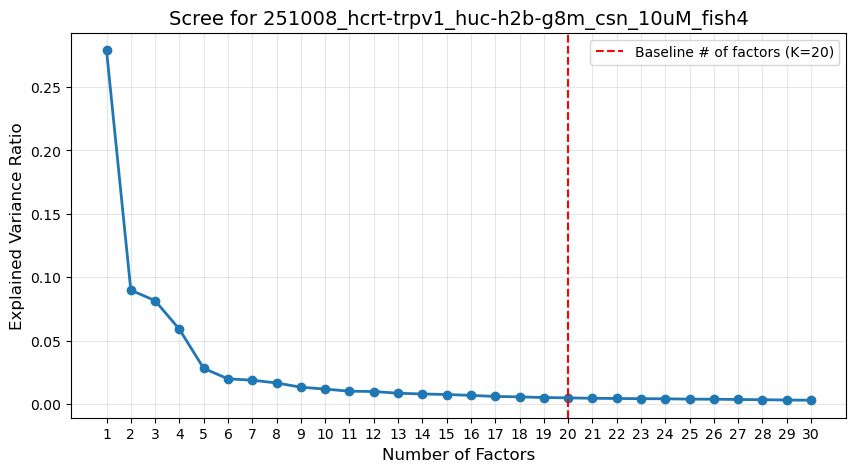

Automatically filtered out 8 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 1533)...


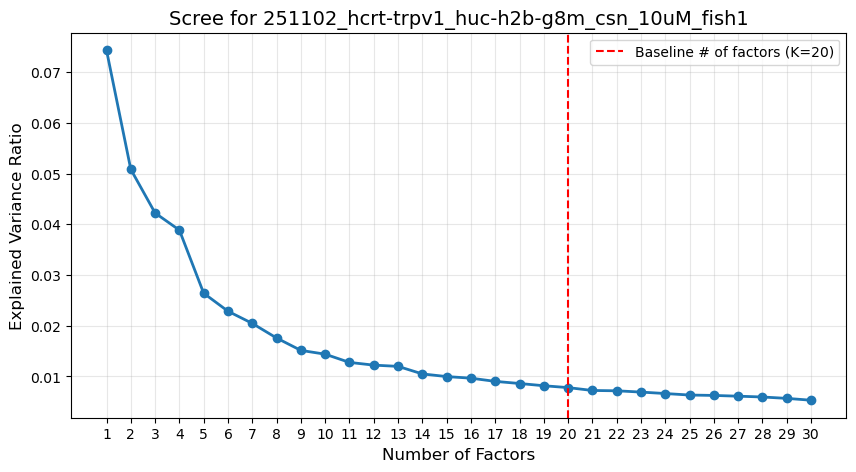

Automatically filtered out 2 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 1019)...


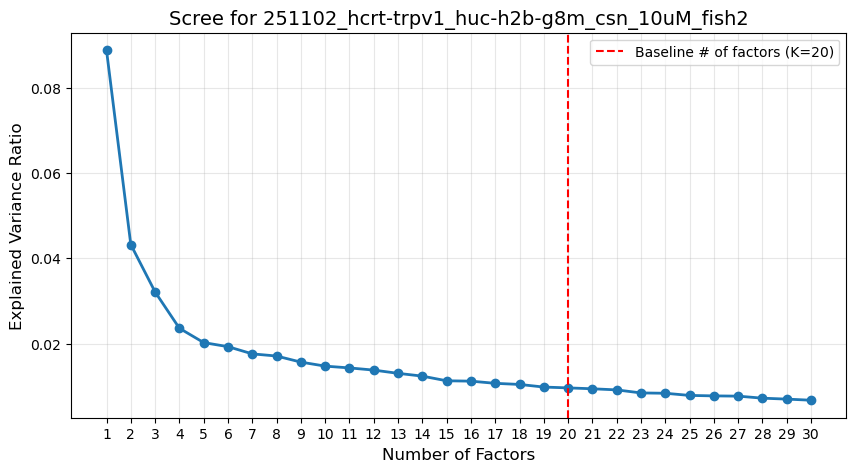

Automatically filtered out 19 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 1693)...


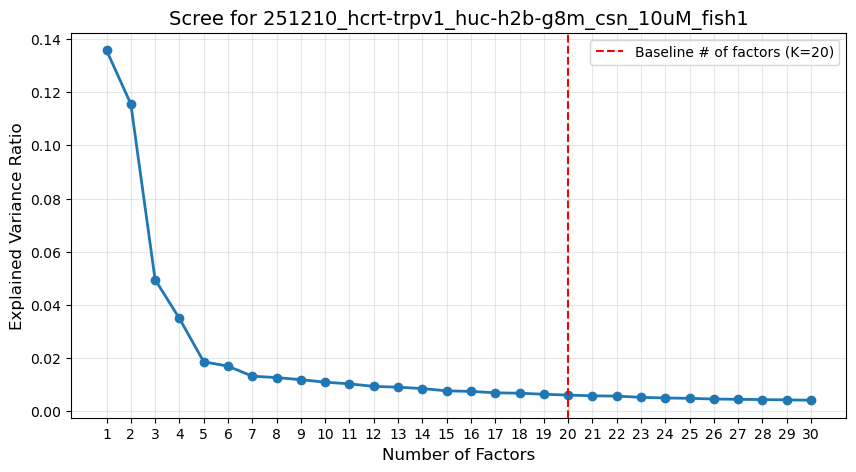

Automatically filtered out 129 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 8601)...


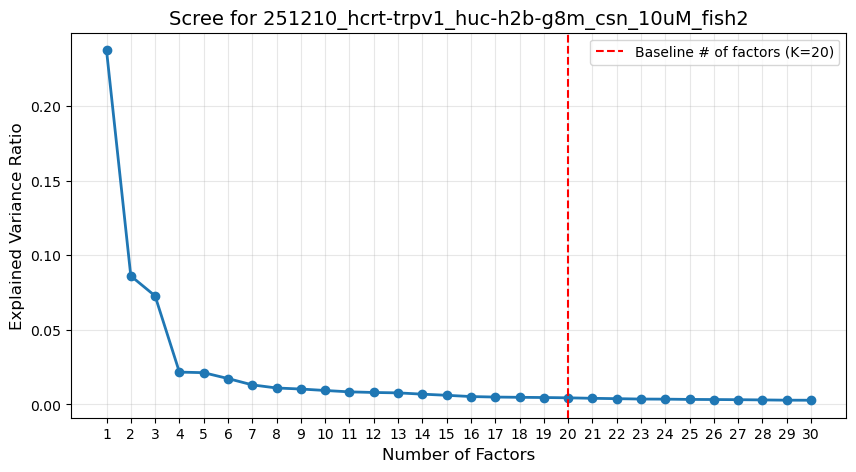

Automatically filtered out 135 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 6986)...


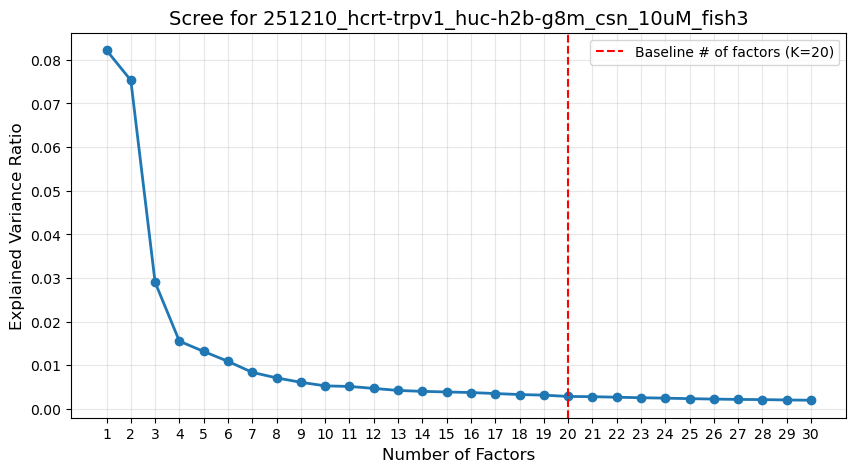

Automatically filtered out 190 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 3027)...


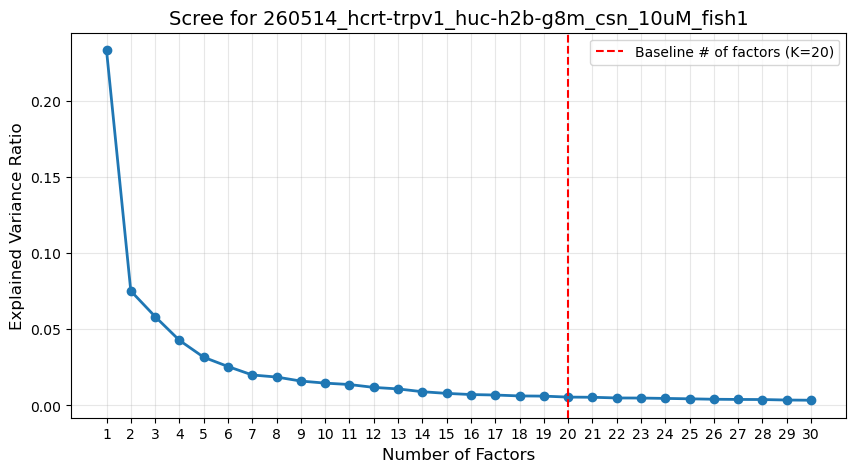

Automatically filtered out 85 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 3678)...


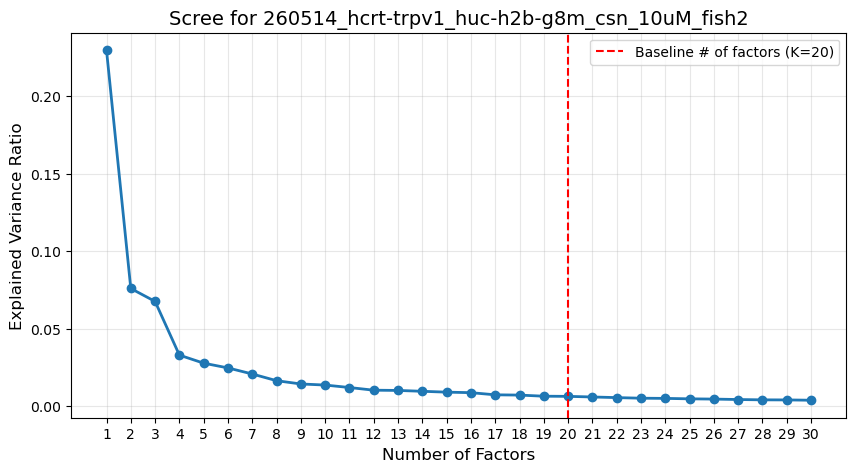

Automatically filtered out 15 dead/flat cells with zero variance.
Evaluating factor spectrum for clean matrix shape: (7200, 1228)...


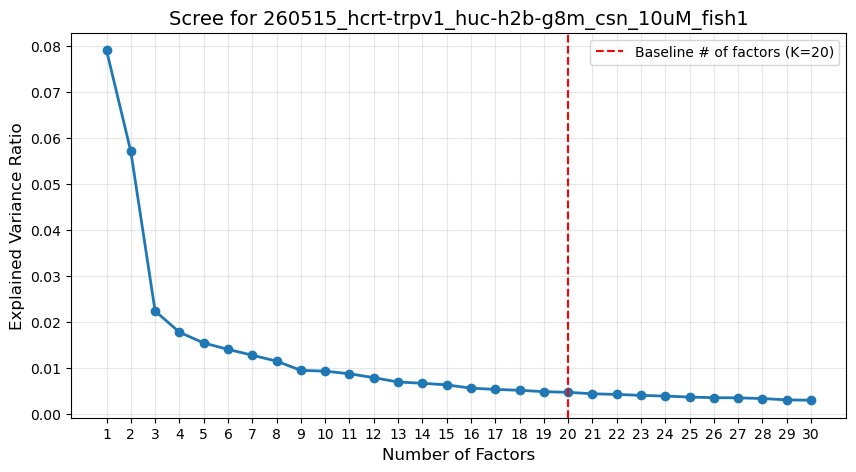

Completed processing for 9 fish.


In [30]:
#Scree Plot for determining optimal number of factors
def plot_scree_curve(raw_phasic_traces, target_fish):

    try:
        clean_raw_traces = raw_phasic_traces[np.var(raw_phasic_traces, axis=1) > 0]
        n_dropped = len(raw_phasic_traces) - len(clean_raw_traces)

        if n_dropped > 0:
            print(f"Automatically filtered out {n_dropped} dead/flat cells with zero variance.")

        z_phasic_traces = zscore(clean_raw_traces, axis=1)
        data_matrix = z_phasic_traces.T
        print(f"Evaluating factor spectrum for clean matrix shape: {data_matrix.shape}...")

        n_factors = 30 #max number of factor it will test
        svd = TruncatedSVD(n_components=n_factors, random_state=42)
        svd.fit(data_matrix)

        plt.figure(figsize=(10, 5))
        plt.plot(range(1, n_factors + 1), svd.explained_variance_ratio_, 'o-', linewidth=2, color='#1f77b4')
        plt.axvline(x=20, color='r', linestyle='--', label="Baseline # of factors (K=20)")
        plt.title(f"Scree for {target_fish}", fontsize=14)
        plt.xlabel("Number of Factors", fontsize=12)
        plt.ylabel("Explained Variance Ratio", fontsize=12)
        plt.xticks(range(1, n_factors + 1))
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"Error occurred while plotting scree curve for {target_fish}: {e}")


print("Started processing fish folders")

for fish_id in expt_fish_list:
    if fish_id in phasic_data:
        raw_phasic_traces = phasic_data[fish_id]
        plot_scree_curve(raw_phasic_traces, fish_id)
    else:
        print(f"Fish data matrix not found in memory for: {fish_id}\n")

print(f"Completed processing for {len(tonic_data)} fish.")


As shown in the elbow plots for the 9 expt fish, the k (number of factors ) where the EVR was at a solid point and adding more clusters yielded diminishing returns was on average 5. 

Started processing fish folders
Automatically filtered out 28 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (5833, 7200)...


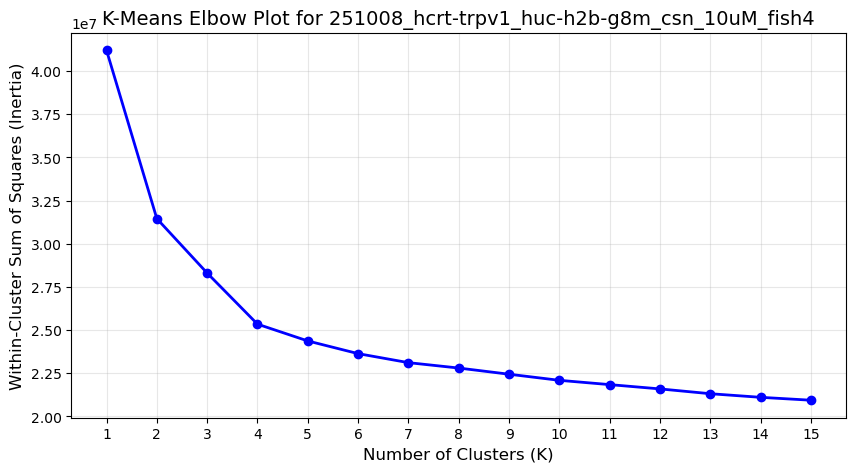

Automatically filtered out 8 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (1533, 7200)...


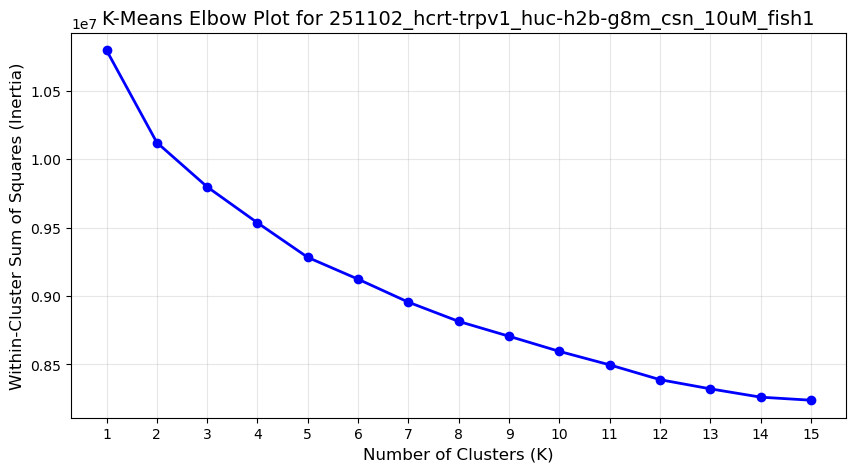

Automatically filtered out 2 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (1019, 7200)...


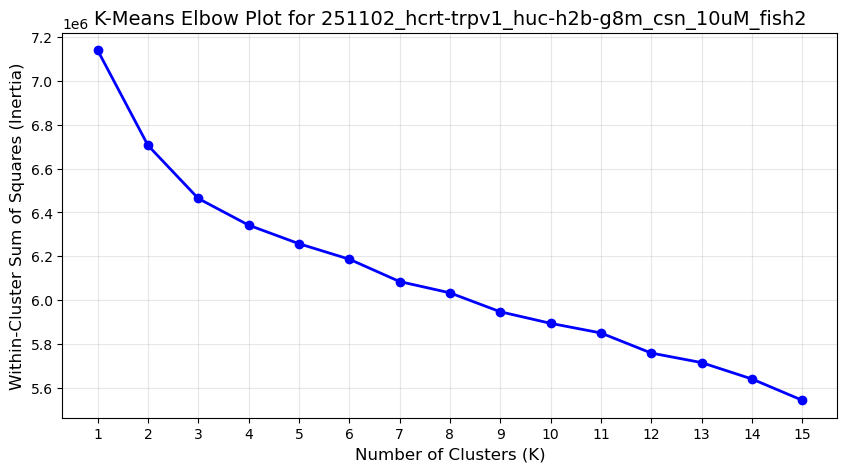

Automatically filtered out 19 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (1693, 7200)...


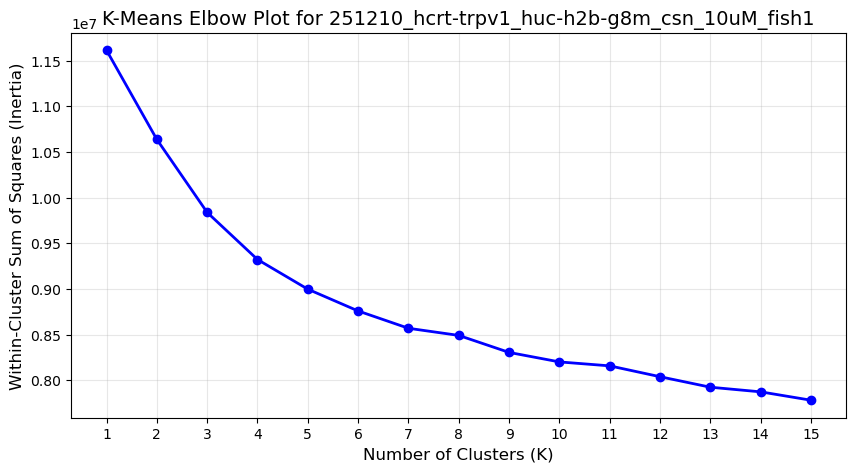

Automatically filtered out 129 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (8601, 7200)...


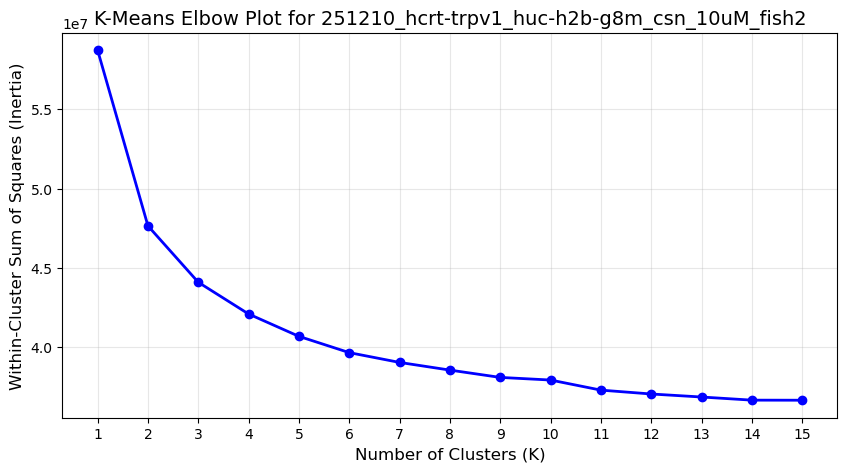

Automatically filtered out 135 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (6986, 7200)...


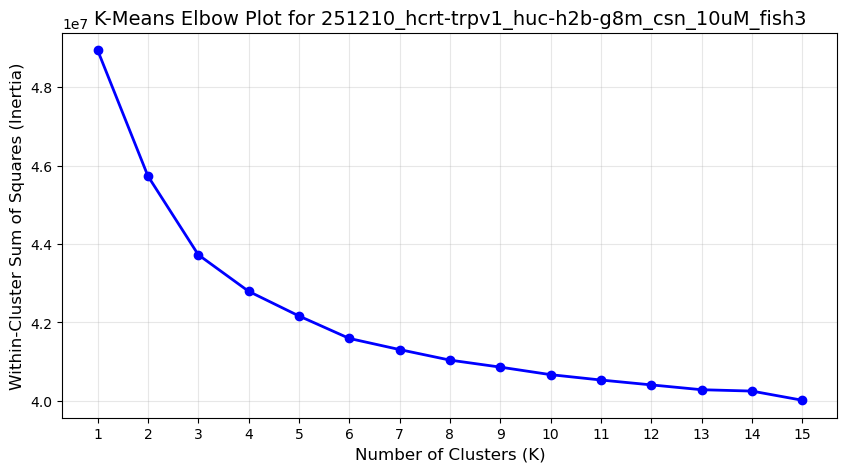

Automatically filtered out 190 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (3027, 7200)...


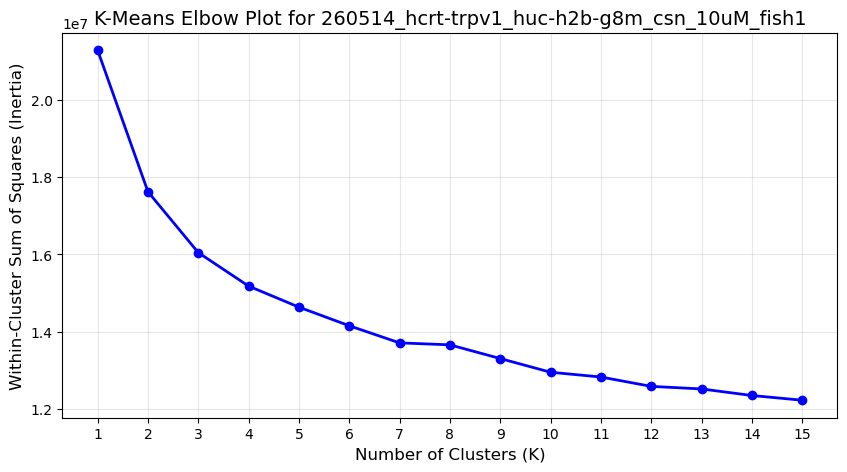

Automatically filtered out 85 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (3678, 7200)...


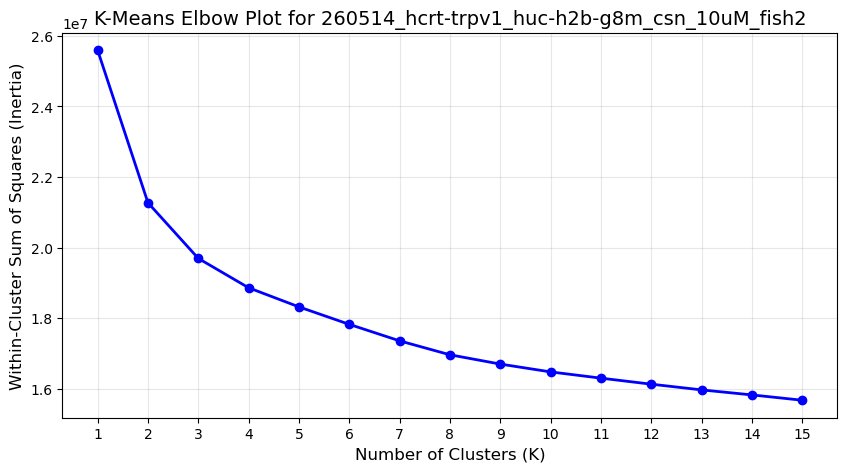

Automatically filtered out 15 dead/flat cells with zero variance.
Evaluating clusters for matrix shape: (1228, 7200)...


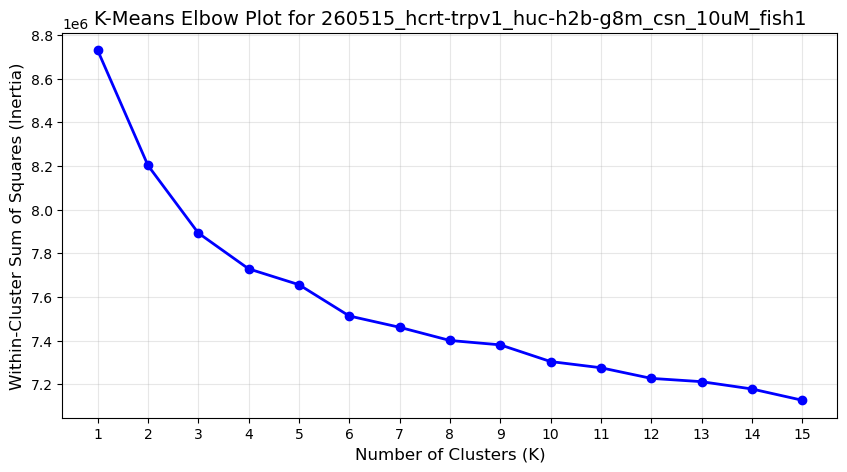

In [38]:
#Elbow Plot for determining optimal number of clusters
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.cluster import KMeans

def plot_cluster_elbow_curve(raw_phasic_traces, target_fish):
    try:
        clean_raw_traces = raw_phasic_traces[np.var(raw_phasic_traces, axis=1) > 0]
        n_dropped = len(raw_phasic_traces) - len(clean_raw_traces)
        if n_dropped > 0:
            print(f"Automatically filtered out {n_dropped} dead/flat cells with zero variance.")
            
        z_phasic_traces = zscore(clean_raw_traces, axis=1)
        
        # KMEANS clusters rows, rows are cells, so we are good!
    
        data_matrix = z_phasic_traces
        print(f"Evaluating clusters for matrix shape: {data_matrix.shape}...")
        
        max_clusters = 15  #number of max clusters to test for the elbow method
        wcss = []          
        
        
        cluster_range = range(1, max_clusters + 1)
        for k in cluster_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
            kmeans.fit(data_matrix)
            wcss.append(kmeans.inertia_) # inertia_ is the WCSS
            
      
        plt.figure(figsize=(10, 5))
        plt.plot(cluster_range, wcss, 'o-', linewidth=2, color='blue')
        plt.title(f"K-Means Elbow Plot for {target_fish}", fontsize=14)
        plt.xlabel("Number of Clusters (K)", fontsize=12)
        plt.ylabel("Within-Cluster Sum of Squares (Inertia)", fontsize=12)
        plt.xticks(cluster_range)
        plt.grid(True, alpha=0.3)
        plt.show()
        
    except Exception as e:
        print(f"Error occurred while plotting elbow curve for {target_fish}: {e}")

print("Started processing fish folders")
for fish_id in expt_fish_list:
    if fish_id in phasic_data:
        raw_phasic_traces = phasic_data[fish_id]
        plot_cluster_elbow_curve(raw_phasic_traces, fish_id)
    else:
        print(f"Fish data matrix not found in for: {fish_id}\n")


Started processing fish folders
Evaluating cell silhouette profile across factors for matrix: (5833, 5)
Highest silhouette score is for 4 clusters with a score of 0.443


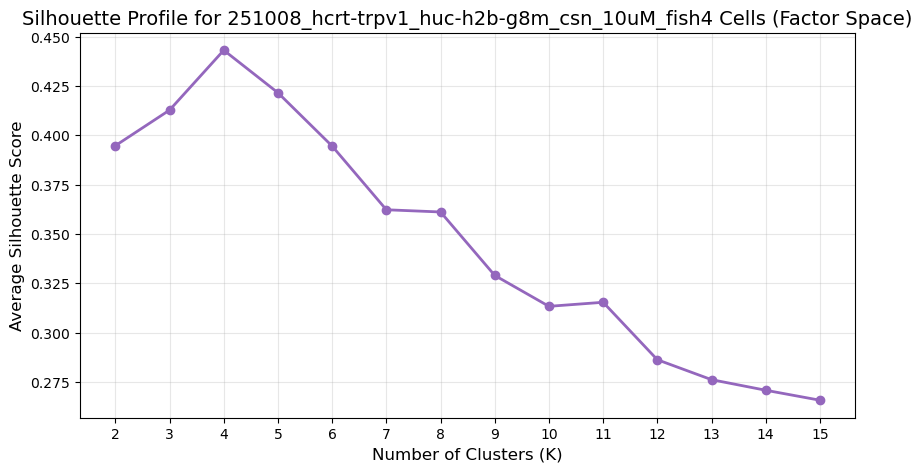

Evaluating cell silhouette profile across factors for matrix: (1533, 5)
Highest silhouette score is for 7 clusters with a score of 0.393


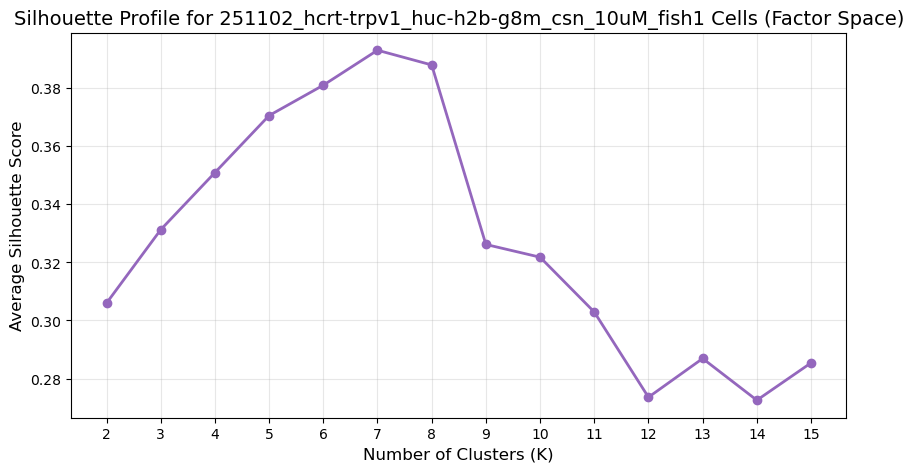

Evaluating cell silhouette profile across factors for matrix: (1019, 5)
Highest silhouette score is for 7 clusters with a score of 0.428


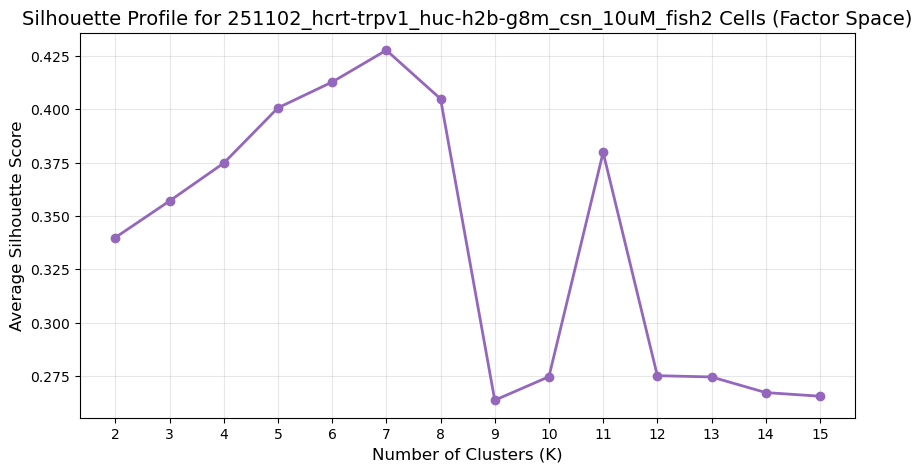

Evaluating cell silhouette profile across factors for matrix: (1693, 5)
Highest silhouette score is for 7 clusters with a score of 0.447


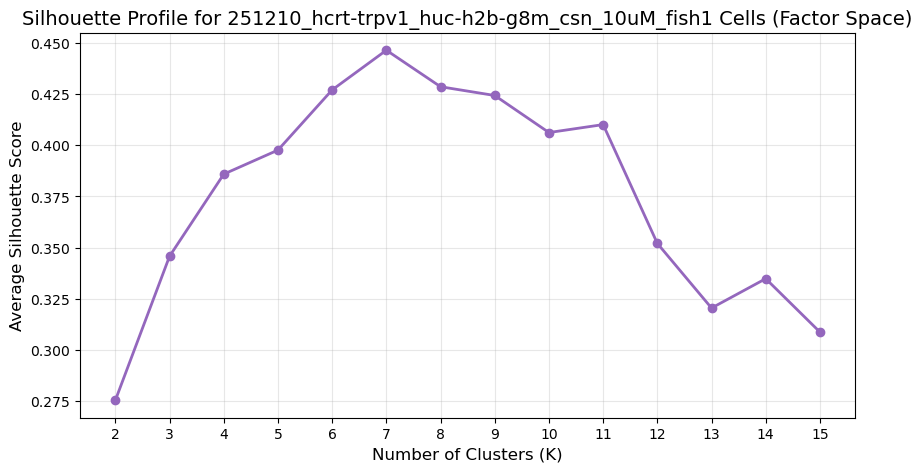

Evaluating cell silhouette profile across factors for matrix: (8601, 5)
Highest silhouette score is for 2 clusters with a score of 0.398


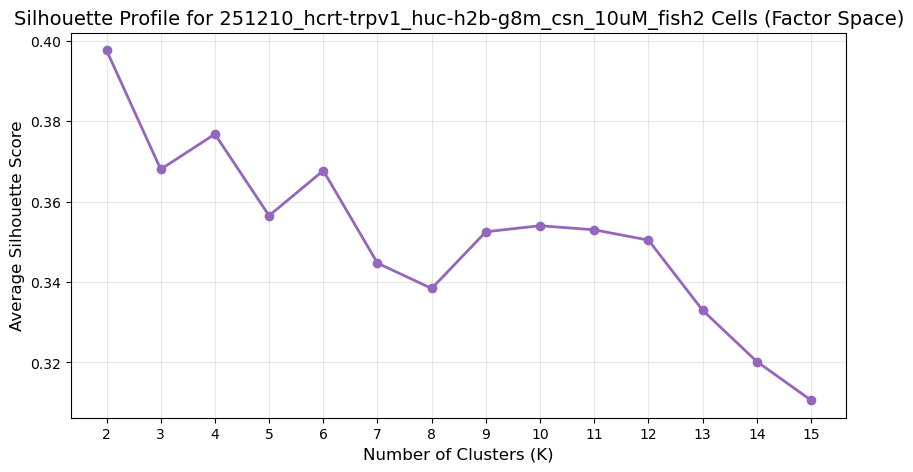

Evaluating cell silhouette profile across factors for matrix: (6986, 5)
Highest silhouette score is for 3 clusters with a score of 0.557


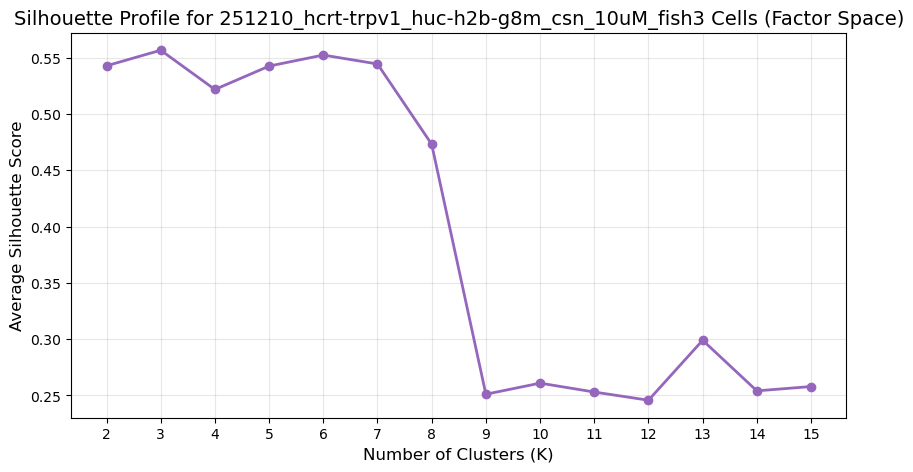

Evaluating cell silhouette profile across factors for matrix: (3027, 5)
Highest silhouette score is for 7 clusters with a score of 0.364


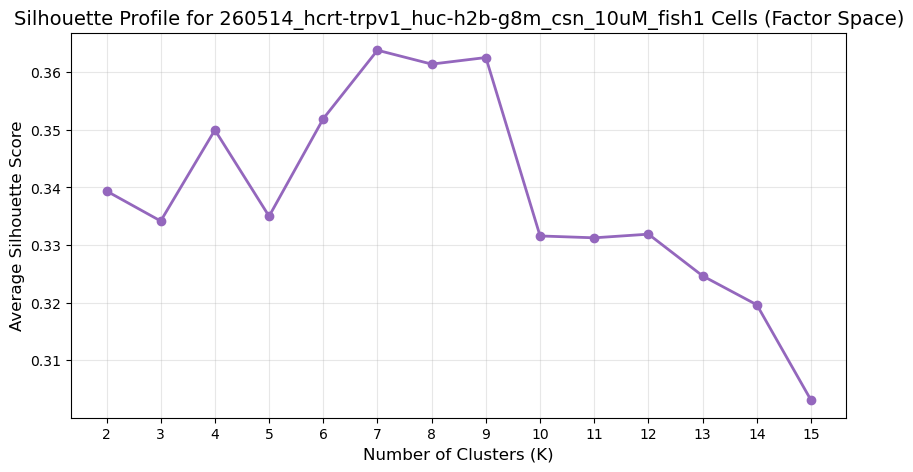

Evaluating cell silhouette profile across factors for matrix: (3678, 5)
Highest silhouette score is for 2 clusters with a score of 0.351


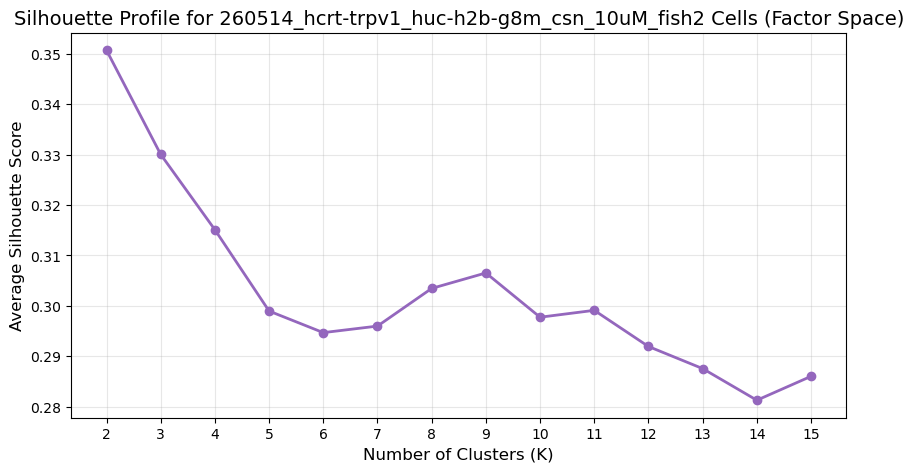

Evaluating cell silhouette profile across factors for matrix: (1228, 5)
Highest silhouette score is for 6 clusters with a score of 0.503


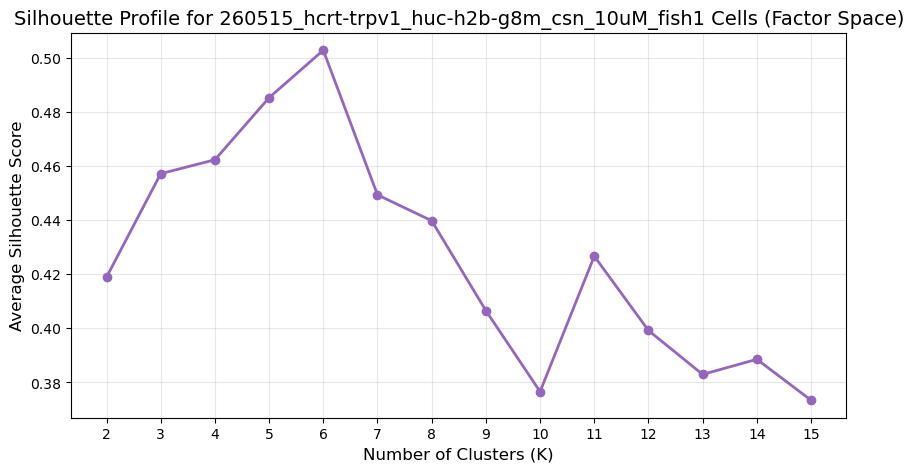

In [49]:
def plot_silhouette_curve(raw_phasic_traces, target_fish):
    try:
        clean_raw_traces = raw_phasic_traces[np.var(raw_phasic_traces, axis=1) > 0]
        z_phasic_traces = zscore(clean_raw_traces, axis=1)
        # found earlier that 5 factors is optimal for this dataset, so we will use that for the factor analysis
        n_optimal_factors = 5
        fa = FactorAnalysis(n_components=n_optimal_factors, random_state=42)
        fa.fit(z_phasic_traces.T)

        data_matrix = fa.components_.T
        print(f"Evaluating cell silhouette profile across factors for matrix: {data_matrix.shape}")

        min_clusters = 2
        max_clusters = 15  # number of max clusters to test for the silhouette method
        silhouette_scores = []
        cluster_range = list(range(min_clusters, max_clusters + 1))

        for k in cluster_range:
            # Fix n_init=5 to eliminate the centroid local minimum bumps!
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
            cluster_labels = kmeans.fit_predict(data_matrix)

            # Use sample_size=10000 to cap RAM usage and calculate in seconds!
            score = silhouette_score(data_matrix, cluster_labels, sample_size=10000, random_state=42)
            silhouette_scores.append(score)

        if silhouette_scores:
            best_idx = int(np.argmax(silhouette_scores))
            best_k = cluster_range[best_idx]
            best_score = silhouette_scores[best_idx]
            print(f'Highest silhouette score is for {best_k} clusters with a score of {best_score:.3f}')

        plt.figure(figsize=(10, 5))
        plt.plot(cluster_range, silhouette_scores, 'o-', linewidth=2, color='#9467bd')
        plt.title(f"Silhouette Profile for {target_fish} Cells (Factor Space)", fontsize=14)
        plt.xlabel("Number of Clusters (K)", fontsize=12)
        plt.ylabel("Average Silhouette Score", fontsize=12)
        plt.xticks(cluster_range)
        plt.grid(True, alpha=0.3)
        plt.show()

    except Exception as e:
            print(f"Error occurred while plotting silhouette curve for {target_fish}: {e}")

# Loop
print("Started processing fish folders")
for fish_id in expt_fish_list:
    if fish_id in phasic_data:
        plot_silhouette_curve(phasic_data[fish_id], fish_id)
    else:
        print(f"Fish data matrix not found for: {fish_id}\n")

4,7,7,7,2,3,7,2,6 were the respective peaks of the nine fish from silhouette score
This roughly matches the respective elbow plots as welll

Due to four of the fish having the optimal cluster of 7 (mode = 7), and the number of the clusters after seven yield dimenishing returns, the number of clusters chosen was 7. 

Summary:

Optimal number of factors: 5
Optimal number of clusters: 7

In [28]:
import os
import gc
from pathlib import Path
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.backends.backend_pdf import PdfPages

# ==============================================================================
# 1. PARAMETERS & MASTER PROJECT CONFIGURATION
# ==============================================================================
BASE_DIR = Path("/mnt/storage-raid10/Yun/analysis_output/chemogenetic")
PROJ_ID = "hcrt-trpv1_huc-h2b-g8m_csn_120min"

# List of the 9 Experimental Fish
EXPT_FISH_LIST = [
    '251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4',
    '251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2',
    '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1',
    '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2',
    '251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3',
    '260113_hcrt-trpv1_huc-h2b-g8m_csn_5uM_fish1',
    '260113_hcrt-trpv1_huc-h2b-g8m_csn_5uM_fish2',
    '260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1',
    '260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1'
]

# Baseline configuration keys matching Yun's blueprint
N_COMPONENTS = 5 #N_FACTORS = 5
N_CLUSTERS = 7
PHASIC_DPRIME_THRESH = 0.5
RESPONSE_CATEGORIES = ["tonic_pos", "tonic_neg", "phasic_pos", "phasic_neg"]

print("Step one of the clustering notebook (FA + Agglomerative Hierarchical Clustering)")


for fish_id in EXPT_FISH_LIST:
    fish_path = BASE_DIR / PROJ_ID / fish_id
    out_dir = fish_path / f"FA_agglo_clustering_f={N_COMPONENTS}_c={N_CLUSTERS}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\nProcessing Directory: {fish_id}")
    
    for category in RESPONSE_CATEGORIES:
        try:
            if "tonic" in category:
                trace_file = fish_path / "f_tonic.npy"
                if not trace_file.exists(): continue
                traces = np.load(trace_file)
                
                idx_file = fish_path / f"{category}_glm_iaaft_nullp99_idxs.npy"
                if not idx_file.exists(): continue
                cell_idxs = np.load(idx_file)
                selected_traces = traces[cell_idxs]
            else:
                trace_file = fish_path / "f_phasic.npy"
                if not trace_file.exists(): continue
                traces = np.load(trace_file)
                
                dprime_file = fish_path / "phasic_dprime_cells_raw.npy"
                if not dprime_file.exists(): continue
                dprime = np.load(dprime_file)
                
                if category == "phasic_pos":
                    cell_idxs = np.where(dprime >= PHASIC_DPRIME_THRESH)[0]
                else:
                    cell_idxs = np.where(dprime <= -PHASIC_DPRIME_THRESH)[0]
                selected_traces = traces[cell_idxs]

            if len(cell_idxs) < N_COMPONENTS:
                print(f" Skipped {category} because cell count is too low.")
                continue

     
            valid_mask = np.std(selected_traces, axis=1) > 0
            clean_traces = selected_traces[valid_mask]
            clean_idxs = cell_idxs[valid_mask]
            
            z_traces = zscore(clean_traces, axis=1)
            print(f"{category}: Clustering {z_traces.shape[0]} cells across timeline.")


            fa = FactorAnalysis(n_components=N_COMPONENTS, random_state=0)
            latent_space = fa.fit_transform(z_traces) 
            

            joblib.dump(fa, out_dir / f"FA_model_{category}.joblib")

            factor_variance = np.var(latent_space, axis=0)
            fig, ax = plt.subplots(figsize=(6, 4))
            ax.plot(np.arange(1, N_COMPONENTS + 1), factor_variance, marker='o', color='purple')
            ax.set_title(f"Factor Variance — {category} — {fish_id}")
            ax.set_xlabel("Factor Index")
            ax.set_ylabel("Variance Value")
            fig.tight_layout()
            plt.savefig(out_dir / f"factors_variance_{category}.png", dpi=150)
            plt.close()

            fig, ax = plt.subplots(figsize=(10, 5))
            for i in range(N_COMPONENTS):
                ax.plot(fa.components_[i], label=f"F{i+1}", alpha=0.7)
            ax.set_title(f"Factor Time Traces — {category} — {fish_id}")
            ax.set_xlabel("Timepoint Volumes")
            ax.set_ylabel("Component Weight Loading")
            ax.legend(loc='upper right', fontsize=6, ncol=5)
            fig.tight_layout()
            plt.savefig(out_dir / f"factor_time_traces_{category}.png", dpi=200)
            plt.close()

            pdf_path = out_dir / f"top10cells_allfactors_{category}.pdf"
            with PdfPages(pdf_path) as pdf:
                for i in range(min(5, N_COMPONENTS)):
                    factor_trace = fa.components_[i]
                    correlations = np.array([
                        np.corrcoef(z_traces[j], factor_trace)[0, 1]
                        if np.all(np.isfinite(z_traces[j])) else -np.inf
                        for j in range(z_traces.shape[0])
                    ])
                    top_cell_picks = np.argsort(correlations)[-10:]
                    
                    fig, ax = plt.subplots(figsize=(6, 4))
                    for j in top_cell_picks:
                        ax.plot(z_traces[j], alpha=0.6)
                    ax.set_title(f"Top 10 Cells — Factor {i+1} — {category}")
                    ax.set_xlabel("Timepoint")
                    ax.set_ylabel("Z-score Signal")
                    fig.tight_layout()
                    pdf.savefig(fig)
                    plt.close(fig)


            agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
            cluster_labels = agglo.fit_predict(latent_space) + 1 
            
            np.save(out_dir / f"cluster_labels_{category}.npy", cluster_labels)
            np.save(out_dir / f"selected_cell_idxs_{category}.npy", clean_idxs)


            if latent_space.shape[0] <= 30000:
                plot_data = latent_space.copy()
                if plot_data.shape[0] > 5000:
                    sampled_picks = np.random.choice(plot_data.shape[0], 5000, replace=False)
                    plot_data = plot_data[sampled_picks]
                    
                linkage_tree = linkage(plot_data, method='ward')
                fig, ax = plt.subplots(figsize=(10, 5))
                dendrogram(linkage_tree, no_labels=True, ax=ax)
                ax.set_title(f"Hierarchical Clustering Dendrogram — {fish_id} — {category}")
                fig.tight_layout()
                plt.savefig(out_dir / f"dendrogram_{category}.png", dpi=200)
                plt.close()

            print(f" {category}: Partitioned cells cleanly. Plots saved to disk.")
            
        except Exception as e:
            print(f" Error executing pipeline category {category}: {e}")
            
    gc.collect()


print("finsished fa and clustering for all fish")

Step one of the clustering notebook (FA + Agglomerative Hierarchical Clustering)

Processing Directory: 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4


KeyboardInterrupt: 

In [ ]:
#one fish example for testing
base_dir = Path("/mnt/storage-raid10/Yun/analysis_output/chemogenetic")
proj_id = "hcrt-trpv1_huc-h2b-g8m_csn_120min"
fish_id = "251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4"
fish_dir = base_dir / proj_id / fish_id

f_tonic = np.load(fish_dir / "f_tonic.npy")
tonic_pos_idx = np.load(fish_dir / "tonic_pos_glm_iaaft_nullp99_idxs.npy")
tonic_neg_idx = np.load(fish_dir / "tonic_neg_glm_iaaft_nullp99_idxs.npy")

all_tonic_idx = np.concatenate([tonic_pos_idx, tonic_neg_idx])
f_tonic_responders = f_tonic[all_tonic_idx, :]

print(f"{f_tonic_responders.shape[0]} tonic responder cells for analysis.")



z_traces = zscore(f_tonic_responders, axis=1)


fa = FactorAnalysis(n_components=5, random_state=42)
latent_features = fa.fit_transform(z_traces.T) 


cell_footprints = fa.components_.T

clustering = AgglomerativeClustering(n_clusters=7, linkage='ward')
cluster_labels = clustering.fit_predict(cell_footprints)

print(f"Divided responder cells into 7 functional clusters!")



In [52]:
def run_final_cell_clustering(raw_phasic_traces, target_fish):
    try:
        # Clean zero-variance flat cells 
        clean_raw_traces = raw_phasic_traces[np.var(raw_phasic_traces, axis=1) > 0]
        z_phasic_traces = zscore(clean_raw_traces, axis=1)
        
        # Transpose ONLY for the Factor Analysis step (Timepoints x Cells)
        data_matrix = z_phasic_traces.T
        
        # Optimal number of factors determined from the Scree plot
        n_optimal_factors = 5
        fa = FactorAnalysis(n_components=n_optimal_factors, random_state=42)
        fa.fit(data_matrix)


    
        cell_factor_features = fa.components_.T
        print(f"Clustering cells for {target_fish} using matrix footprint: {cell_factor_features.shape}")
        
        # based on previous step, 7 is used
        n_clusters = 7
        cluster_model = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        cluster_labels = cluster_model.fit_predict(cell_factor_features)
        

        print(f"Grouped {len(cluster_labels)} neurons into {n_clusters} clusters!")
        
    
        for c_id in range(n_clusters):
            print(f" -> Cluster {c_id + 1}: holds {np.sum(cluster_labels == c_id)} cells.")
            
    except Exception as e:
        print(f"Error processing {target_fish}: {e}")

# Run the pipeline loop over your fish dataset
print("Starting execution...")
target_id = '251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4'
if target_id in phasic_data:
    run_final_cell_clustering(phasic_data[target_id], target_id)


Starting execution...
Clustering cells for 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4 using matrix footprint: (5833, 5)
Grouped 5833 neurons into 7 clusters!
 -> Cluster 1: holds 959 cells.
 -> Cluster 2: holds 1285 cells.
 -> Cluster 3: holds 816 cells.
 -> Cluster 4: holds 852 cells.
 -> Cluster 5: holds 1101 cells.
 -> Cluster 6: holds 460 cells.
 -> Cluster 7: holds 360 cells.


In [ ]:
silhouette_peaks = {
        "251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4":4,
        "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1":7,
        "251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2":7,
        "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1":7,
        "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2":2, 
        "251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3":3,
        "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1":7,
        "260514_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2":2,
        "260515_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1":6
}


final_cluster_labels_by_fish = {}

print("hierarchical clustering across factor space...\n")

for fish_id in expt_fish_list:
    if fish_id in phasic_data:
        raw_traces = phasic_data[fish_id]
        
        #Zero-variance data cleaning
        clean_mask = np.var(raw_traces, axis=1) > 0
        z_traces = zscore(raw_traces[clean_mask, :], axis=1)
        
        # FA
        fa = FactorAnalysis(n_components=5, random_state=42)
        fa.fit(z_traces.T)
        cell_features = fa.components_.T  # Shape: Cells x 5 Factors
        

        optimal_k = silhouette_peaks[fish_id]
        
        # Ward's Agglomerative Hierarchical Clustering
        hc_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
        labels = hc_model.fit_predict(cell_features)
        
        # Save cluster labels to memory
        final_cluster_labels_by_fish[fish_id] = labels
        
        print(f"{fish_id} complete!")
        print(f"Clustered {len(labels)} cells into {optimal_k} groups based on 5 latent factors.")
        print(f"Label distribution: {np.bincount(labels)}\n")

print("All experimental fish functional networks have been successfully extracted!")


hierarchical clustering across factor space...

251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4 complete!
Clustered 5833 cells into 4 groups based on 5 latent factors.
Label distribution: [2060 1745  816 1212]

251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1 complete!
Clustered 1533 cells into 7 groups based on 5 latent factors.
Label distribution: [384 183  97  92 637  94  46]

251102_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2 complete!
Clustered 1019 cells into 7 groups based on 5 latent factors.
Label distribution: [316  67  66 367  22 156  25]

251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish1 complete!
Clustered 1693 cells into 7 groups based on 5 latent factors.
Label distribution: [513 368 158 433  73  93  55]

251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish2 complete!
Clustered 8601 cells into 2 groups based on 5 latent factors.
Label distribution: [5347 3254]

251210_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish3 complete!
Clustered 6986 cells into 3 groups based on 5 latent factors.
Label distribution: [

##Steps 1 and 2 for one fish folder

In [65]:
#Params

N_COMPONENTS = 5
N_CLUSTERS = 7

sec_per_volume = 1
volume_per_sec = 1


baseline_start = 0 * 60 * volume_per_sec
baseline_end   = 45 * 60 * volume_per_sec

drug_start     = 46 * 60 * volume_per_sec
drug_end       = 90 * 60 * volume_per_sec

wash_start     = 91 * 60 * volume_per_sec
wash_end       = 120 * 60 * volume_per_sec


f_tonic_window_size = 600  

def run_clustering(proj_id, fish_list):
    print(f"\nRunning Clustering for Project: {proj_id}")
    
    for fish_id in tqdm(fish_list, desc="Processing Fish"):
        fish_dir = BASE_DIR / proj_id / fish_id
        
       
        out_dir = fish_dir / f"FA_agglo_clustering_f={N_COMPONENTS}_c={N_CLUSTERS}"
        out_dir.mkdir(parents=True, exist_ok=True)
        
        print(f"\nExperiment: {fish_id}")
        
        for resp_type in RESPONSE_TYPES:
            try:
           
                traces, cell_idxs = load_traces_and_indices(fish_dir, resp_type)
                n_cells = len(cell_idxs)
                print(f"{resp_type} — Loaded {n_cells} cells, trace shape = {traces.shape}")
                
                if n_cells < N_COMPONENTS:
                    print(f"Skipping {resp_type}: Not enough cells ({n_cells}) for FA ({N_COMPONENTS} components).")
                    continue
                
                traces_z = zscore(traces, axis=1)
                traces_z = np.nan_to_num(traces_z)  
                
                # Factor Analysis
                fa = FactorAnalysis(n_components=N_COMPONENTS, random_state=42)
                fa_transformed = fa.fit_transform(traces_z)  # Shape: (n_cells, N_COMPONENTS) 
                
                # Clustering
                agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS, metric='euclidean', linkage='ward')
                cluster_labels = agglo.fit_predict(fa_transformed)
                
                # Save 
                joblib.dump(fa, out_dir / f"FA_model_{resp_type}.joblib")
                joblib.dump(agglo, out_dir / f"Agglo_model_{resp_type}.joblib")
                np.save(out_dir / f"cluster_labels_{resp_type}.npy", cluster_labels)
                np.save(out_dir / f"selected_cell_idxs_{resp_type}.npy", cell_idxs)
                
                print(f"Finished {resp_type} | Saved results to {out_dir}")
                
            except Exception as e:
                print(f"Error processing {resp_type} for {fish_id}: {e}")
            
            gc.collect()

run_clustering(PROJ_ID, expt_fish_list)


Running Clustering for Project: hcrt-trpv1_huc-h2b-g8m_csn_120min


Processing Fish:   0%|          | 0/9 [00:00<?, ?it/s]


Experiment: 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4


Processing Fish:   0%|          | 0/9 [02:22<?, ?it/s]


KeyboardInterrupt: 


Processing Category: tonic_pos
Cells active for clustering after normalization: 23316
Saved FA structural footprint model to: ./FA_agglo_clustering_f=4_c=7/251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4/FA_model_tonic_pos.joblib


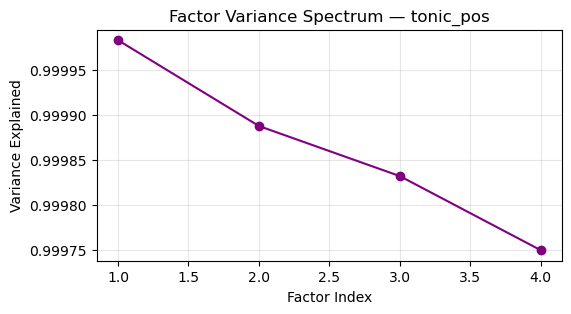

Fitting Agglomerative Clustering Tree on matrix: (23316, 4)
Completed partitioning for tonic_pos. Cluster profiles saved to dir.

Processing Category: phasic_pos
Cells active for clustering after normalization: 5833
Saved FA structural footprint model to: ./FA_agglo_clustering_f=4_c=7/251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4/FA_model_phasic_pos.joblib


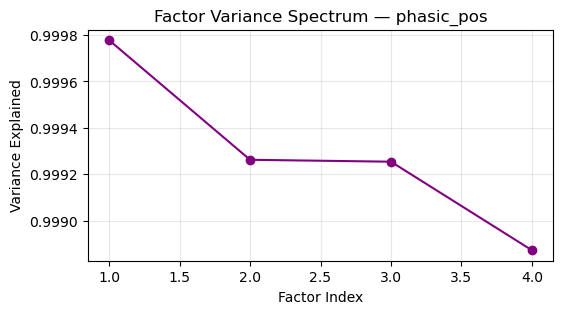

Fitting Agglomerative Clustering Tree on matrix: (5833, 4)
Completed partitioning for phasic_pos. Cluster profiles saved to dir.


In [69]:
import os
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.decomposition import FactorAnalysis
from sklearn.cluster import AgglomerativeClustering

N_components = 4
N_clusters = 7
target_fish = '251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4'

# Output directory for models and index configurations
out_dir = f"./FA_agglo_clustering_f={N_components}_c={N_clusters}/{target_fish}"
os.makedirs(out_dir, exist_ok=True)

# Define our datasets dictionary from your loading loop
datasets_to_process = {
    "tonic_pos": f_tonic_responders, # Update these names to match your variable variables
    "phasic_pos": f_phasic_responders
}

for label, trace_subset in datasets_to_process.items():
    print(f"\nProcessing Category: {label}")
    

    z_traces = zscore(trace_subset, axis=1)
    valid_mask = np.all(np.isfinite(z_traces), axis=1)
    z_traces = z_traces[valid_mask]
    
    print(f"Cells active for clustering after normalization: {z_traces.shape[0]}")
    fa = FactorAnalysis(n_components=N_components, random_state=0)
    latent_space = fa.fit_transform(z_traces)
    #Save
    fa_model_path = os.path.join(out_dir, f"FA_model_{label}.joblib")
    joblib.dump(fa, fa_model_path)
    print(f"Saved FA structural footprint model to: {fa_model_path}")
    

    factor_variance = np.var(latent_space, axis=0)
    plt.figure(figsize=(6, 3))
    plt.plot(np.arange(1, N_components + 1), factor_variance, marker='o', color='purple')
    plt.title(f"Factor Variance Spectrum — {label}")
    plt.xlabel("Factor Index")
    plt.ylabel("Variance Explained")
    plt.grid(True, alpha=0.3)
    plt.show()


    print(f"Fitting Agglomerative Clustering Tree on matrix: {latent_space.shape}")
    clustering = AgglomerativeClustering(n_clusters=N_clusters, linkage='ward')
    cluster_labels = clustering.fit_predict(latent_space) + 1 # 1-indexed to match her code
    
    for c_id in range(1, N_clusters + 1):
        cluster_mask = (cluster_labels == c_id)
        cluster_out_path = os.path.join(out_dir, f"{label}_c{c_id}_idxs.npy")
        np.save(cluster_out_path, cluster_mask)
        
    print(f"Completed partitioning for {label}. Cluster profiles saved to dir.")


/tmp/ipykernel_242502/4203616608.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_colors = plt.cm.get_cmap('tab20', N_clusters)


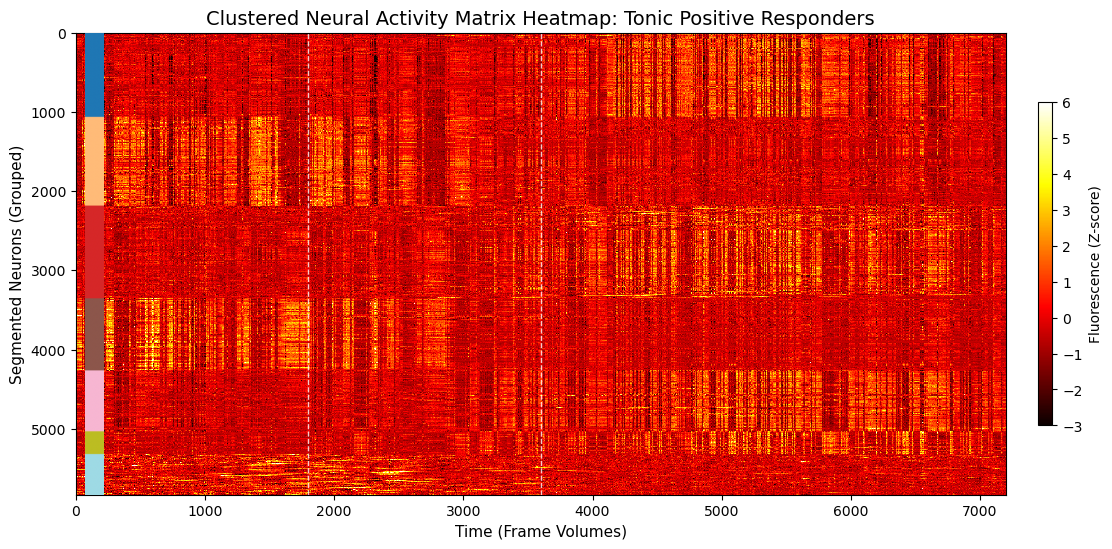

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def plot_raster_heatmap(label_name, z_traces, cluster_labels):

    sort_order = np.argsort(cluster_labels)
    sorted_traces = z_traces[sort_order]
    sorted_ids = cluster_labels[sort_order]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    

    im = ax.imshow(sorted_traces, aspect='auto', cmap='hot', interpolation='none', vmin=-3, vmax=6)
    ax.set_title(f"Clustered Neural Activity Matrix Heatmap: {label_name}", fontsize=14)
    ax.set_ylabel("Segmented Neurons (Grouped)", fontsize=11)
    ax.set_xlabel("Time (Frame Volumes)", fontsize=11)
    

    ax.axvline(x=1800, color='white', linestyle='--', linewidth=1, alpha=0.8)
    ax.axvline(x=3600, color='white', linestyle='--', linewidth=1, alpha=0.8)
    inset_ax = inset_axes(ax, width="2%", height="100%", loc='center left',
                          bbox_to_anchor=(0.01, 0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    
    cluster_colors = plt.cm.get_cmap('tab20', N_clusters)
    color_strip = np.array([cluster_colors(c - 1) for c in sorted_ids]).reshape(len(sorted_ids), 1, 4)
    inset_ax.imshow(color_strip, aspect='auto')
    inset_ax.axis('off')
    
    # Append color bar 
    cbar_ax = inset_axes(ax, width="1.5%", height="70%", loc='right',
                         bbox_to_anchor=(0.05, 0, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    plt.colorbar(im, cax=cbar_ax, label="Fluorescence (Z-score)")
    plt.show()

# Run visualization for tonic responders
plot_raster_heatmap("Tonic Positive Responders", z_traces, cluster_labels)


In [ ]:
for fish_id in expt_fish_list:
    fish_dir = BASE_DIR / PROJ_ID / fish_id
    #output dir 
    out_dir = fish_dir / f"FA_agglo_clustering_f={N_COMPONENTS}_c={N_CLUSTERS}"
    out_dir.mkdir(parents=True, exist_ok=True)
    
    print(f"\Processing Folder: {fish_id}")
    
    for resp_type in RESPONSE_TYPES:
        try:
       
            if "tonic" in resp_type:
                trace_path = fish_dir / "f_tonic.npy"
                if not trace_path.exists(): continue
                raw_traces = np.load(trace_path)
                
                idx_path = fish_dir / f"{resp_type}_glm_iaaft_nullp99_idxs.npy"
                if not idx_path.exists(): continue
                cell_idxs = np.load(idx_path)
                selected_traces = raw_traces[cell_idxs]
                
            elif "phasic" in resp_type:
                trace_path = fish_dir / "f_phasic.npy"
                if not trace_path.exists(): continue
                raw_traces = np.load(trace_path)
                
                dprime_path = fish_dir / "phasic_dprime_cells_raw.npy"
                if not dprime_path.exists(): continue
                dprime = np.load(dprime_path)
                
                if resp_type == "phasic_pos":
                    cell_idxs = np.where(dprime >= PHASIC_DPRIME_THRESH)[0]
                elif resp_type == "phasic_neg":
                    cell_idxs = np.where(dprime <= -PHASIC_DPRIME_THRESH)[0]
                selected_traces = raw_traces[cell_idxs]

            n_cells = len(cell_idxs)
            if n_cells < N_COMPONENTS:
                print(f"Skipped {resp_type}: Not enough cells ({n_cells}) to fit {N_COMPONENTS} factors.")
                continue

            # Drop zero-variance flat cells to prevent NaN generation during division
            valid_cells_mask = np.std(selected_traces, axis=1) > 0
            clean_traces = selected_traces[valid_cells_mask]
            clean_idxs = cell_idxs[valid_cells_mask]
            
            traces_z = zscore(clean_traces, axis=1)
            data_matrix = traces_z.T
            
            fa = FactorAnalysis(n_components=N_COMPONENTS, random_state=42)
            latent_factors = fa.fit_transform(data_matrix) # Returns: (Timepoints x Factors)
            
            #Hierarchical Clustering

            cell_features = fa.components_.T
            
            agglo = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
            cluster_labels = agglo.fit_predict(cell_features)
            joblib.dump(fa, out_dir / f"FA_model_{resp_type}.joblib")
            np.save(out_dir / f"cluster_labels_{resp_type}.npy", cluster_labels)
            np.save(out_dir / f"selected_cell_idxs_{resp_type}.npy", clean_idxs)
            
            print(f"{resp_type}: Clustered {len(cluster_labels)} neurons smoothly. Models saved.")
            
        except Exception as e:
            print(f"Error executing {resp_type}: {e}")
            
    gc.collect()

print("all 9 loaded successfully")


\Processing Folder: 251008_hcrt-trpv1_huc-h2b-g8m_csn_10uM_fish4
tonic_pos: Clustered 6019 neurons smoothly. Models saved.
